# Data Preparation Pipeline - Minimal Features (Weekly)

## Purpose

Streamlined data preparation pipeline for RL portfolio rebalancing using **minimal evidence-based features** (22 features).

## Key Features

1. **Evidence-Based Features**: 22 features backed by literature (Jiang 2017, Zhang 2020)
2. **Weekly Frequency**: Reduced noise compared to daily data
3. **Per-Ticker Normalization**: Rolling z-score normalization (52-week window)
4. **Clean Pipeline**: Single function call handles all preprocessing

## Feature Set (22 Total)

- **Momentum** (4): 1w, 4w, 13w, 52w returns
- **Volatility** (2): 4w, 52w standard deviation
- **Technical** (6): SMA, EMA, MACD, Bollinger Bands, RSI
- **Volume** (4): OBV, relative volume, volume momentum
- **Risk** (3): Drawdown, stochastic oscillator, downside volatility
- **Price Ratios** (3): Price to SMA/EMA ratios

## Outputs

- `data/processed/train_minimal_features_weekly.parquet`: Training set
- `data/processed/test_minimal_features_weekly.parquet`: Test set (TBD)
- `data/processed/metadata_minimal_weekly.json`: Feature list and metadata
- `results/`: Visualization plots

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Import data preparation and visualization modules
from data_prep import prepare_weekly_data
from viz_data_prep import create_all_plots

# Import configuration
from config import TICKERS, START_DATE, END_DATE

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


## Configuration

In [2]:
# Directories
PROJECT_ROOT = Path().resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results'

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Data parameters
TEST_START_DATE = '2023-09-01'

print("Configuration:")
print(f"  Tickers: {', '.join(TICKERS)}")
print(f"  Date range: {START_DATE} to {END_DATE}")
print(f"  Test split: {TEST_START_DATE}")
print(f"  Frequency: Weekly (1wk)")
print(f"  Features: 22 (minimal, evidence-based)")
print(f"  Output: {DATA_DIR}")

Configuration:
  Tickers: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
  Date range: 2015-01-01 to 2025-11-01
  Test split: 2023-09-01
  Frequency: Weekly (1wk)
  Features: 22 (minimal, evidence-based)
  Output: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed


## Run Data Preparation Pipeline

Execute the complete pipeline:
1. Fetch weekly price data from Yahoo Finance
2. Calculate 22 minimal features
3. Apply per-ticker rolling z-score normalization
4. Split into train/test sets
5. Save processed data

In [3]:
# Run pipeline
train_df, test_df, metadata = prepare_weekly_data(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE,
    test_start_date=TEST_START_DATE,
    output_dir=DATA_DIR
)

print("\n" + "="*80)
print("PIPELINE COMPLETE")
print("="*80)
print(f"Train samples: {len(train_df):,}")
print(f"Test samples:  {len(test_df):,}")
print(f"Features:      {len(metadata['feature_cols'])}")
print(f"Train date range: {train_df['date'].min().date()} to {train_df['date'].max().date()}")
print(f"Test date range:  {test_df['date'].min().date()} to {test_df['date'].max().date()}")
print("="*80)

WEEKLY DATA PREPARATION PIPELINE
Fetching 1wk data for 7 tickers...
  ✓ NVDA: 566 periods
  ✓ MU: 566 periods
  ✓ AAPL: 566 periods
  ✓ AMD: 566 periods
  ✓ ASML: 566 periods
  ✓ MSFT: 566 periods
  ✓ GOOG: 566 periods
✓ Fetched 3962 total rows

Fetching macro features...
  ✓ VIX
  ✓ DXY
  ✓ Oil WTI
  ✓ Treasury 10Y
  ✓ Yield Curve (10Y-2Y)
✓ Fetched 5 macro features
✓ Merged 5 macro features
✓ Calculated 2 calendar features (monthly seasonality)

Calculating minimal features (19 ticker-specific)...
✓ Calculated 19 ticker-specific features

Applying per-ticker z-score normalization (window=52)...
✓ Normalized 19 features per ticker

Normalizing macro features (global z-score)...
✓ Normalized 5 macro features

Splitting data at 2023-09-01...
✓ Train: 3171 rows (2015-01-01 to 2023-08-31)
✓ Test:  791 rows (2023-09-07 to 2025-10-30)

PIPELINE COMPLETE
✓ Train: 2632 samples, 26 features
  - Ticker features: 19
  - Macro features: 5
  - Calendar features: 2 (monthly seasonality)
✓ Test:  79

## Data Quality Checks

In [4]:
feature_cols = metadata['feature_cols']

print("\n" + "="*80)
print("DATA QUALITY CHECKS")
print("="*80)

# Test 1: Check for temporal overlap
print("\n[1] Temporal Separation:")
train_end = train_df['date'].max()
test_start = test_df['date'].min()
gap_days = (test_start - train_end).days
print(f"  Train ends:  {train_end.date()}")
print(f"  Test starts: {test_start.date()}")
print(f"  Gap:         {gap_days} days")
print(f"  ✓ PASS: No temporal overlap" if gap_days > 0 else "  ✗ FAIL: Overlap detected!")

# Test 2: Check for missing values
print("\n[2] Missing Values:")
train_missing = train_df[feature_cols].isnull().sum().sum()
test_missing = test_df[feature_cols].isnull().sum().sum()
train_total = len(train_df) * len(feature_cols)
test_total = len(test_df) * len(feature_cols)
print(f"  Train: {train_missing:,} / {train_total:,} ({100*train_missing/train_total:.2f}%)")
print(f"  Test:  {test_missing:,} / {test_total:,} ({100*test_missing/test_total:.2f}%)")
print(f"  ✓ PASS: Low missing data" if train_missing < 0.01 * train_total else "  ⚠ WARNING: High missing data")

# Test 3: Check normalization
print("\n[3] Normalization (Z-Score):")
train_mean = train_df[feature_cols].mean().mean()
train_std = train_df[feature_cols].std().mean()
print(f"  Train mean: {train_mean:.4f} (target: ~0.00)")
print(f"  Train std:  {train_std:.4f} (target: ~1.00)")
print(f"  ✓ PASS: Properly normalized" if abs(train_mean) < 0.1 and 0.8 < train_std < 1.2 else "  ⚠ WARNING: Check normalization")

# Test 4: Check feature consistency
print("\n[4] Feature Consistency:")
train_cols = set(train_df.columns)
test_cols = set(test_df.columns)
missing_in_test = train_cols - test_cols
extra_in_test = test_cols - train_cols
print(f"  Train columns: {len(train_cols)}")
print(f"  Test columns:  {len(test_cols)}")
if missing_in_test or extra_in_test:
    print(f"  ✗ FAIL: Column mismatch")
    if missing_in_test:
        print(f"    Missing in test: {missing_in_test}")
    if extra_in_test:
        print(f"    Extra in test: {extra_in_test}")
else:
    print(f"  ✓ PASS: Columns match")

# Test 5: Check samples per ticker
print("\n[5] Samples Per Ticker:")
train_counts = train_df.groupby('ticker').size()
test_counts = test_df.groupby('ticker').size()
print(f"  Train: {train_counts.min()} to {train_counts.max()} samples")
print(f"  Test:  {test_counts.min()} to {test_counts.max()} samples")
print(f"  ✓ PASS: Balanced" if train_counts.std() < 0.1 * train_counts.mean() else "  ⚠ WARNING: Imbalanced")

print("\n" + "="*80)


DATA QUALITY CHECKS

[1] Temporal Separation:
  Train ends:  2023-08-31
  Test starts: 2023-09-07
  Gap:         7 days
  ✓ PASS: No temporal overlap

[2] Missing Values:
  Train: 0 / 68,432 (0.00%)
  Test:  0 / 20,566 (0.00%)
  ✓ PASS: Low missing data

[3] Normalization (Z-Score):
  Train mean: 0.0254 (target: ~0.00)
  Train std:  1.0983 (target: ~1.00)
  ✓ PASS: Properly normalized

[4] Feature Consistency:
  Train columns: 34
  Test columns:  34
  ✓ PASS: Columns match

[5] Samples Per Ticker:
  Train: 376 to 376 samples
  Test:  113 to 113 samples
  ✓ PASS: Balanced



## Feature Summary

## Visualizations


Creating visualizations...
  1/5 Price trends...
  2/5 Feature distributions...
  3/5 Feature statistics...
  4/5 Correlation heatmap...
  5/5 Temporal statistics...

Saving plots to /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results...
  ✓ price_trends.png
  ✓ feature_distributions.png
  ✓ feature_stats.png
  ✓ correlation.png
  ✓ temporal_stats.png
✓ All visualizations created



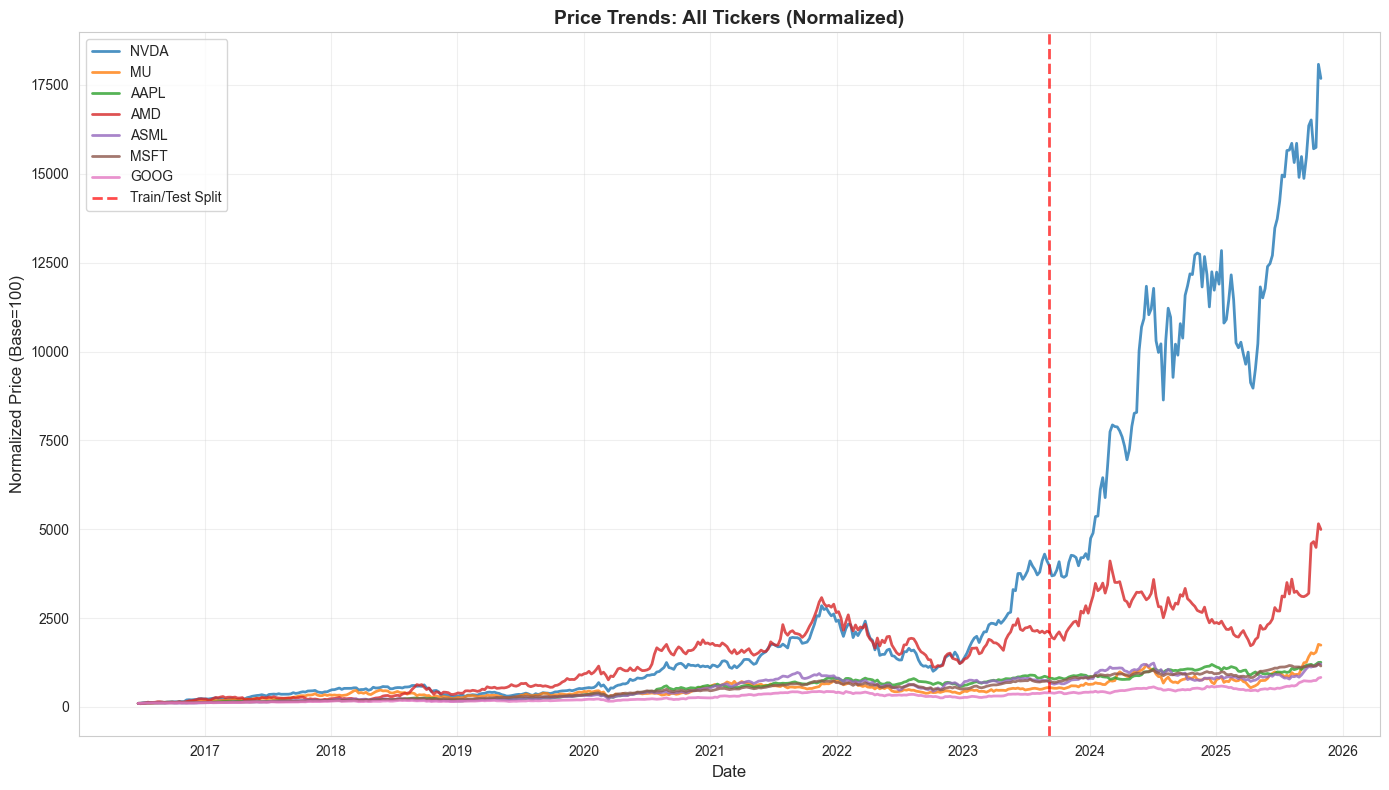

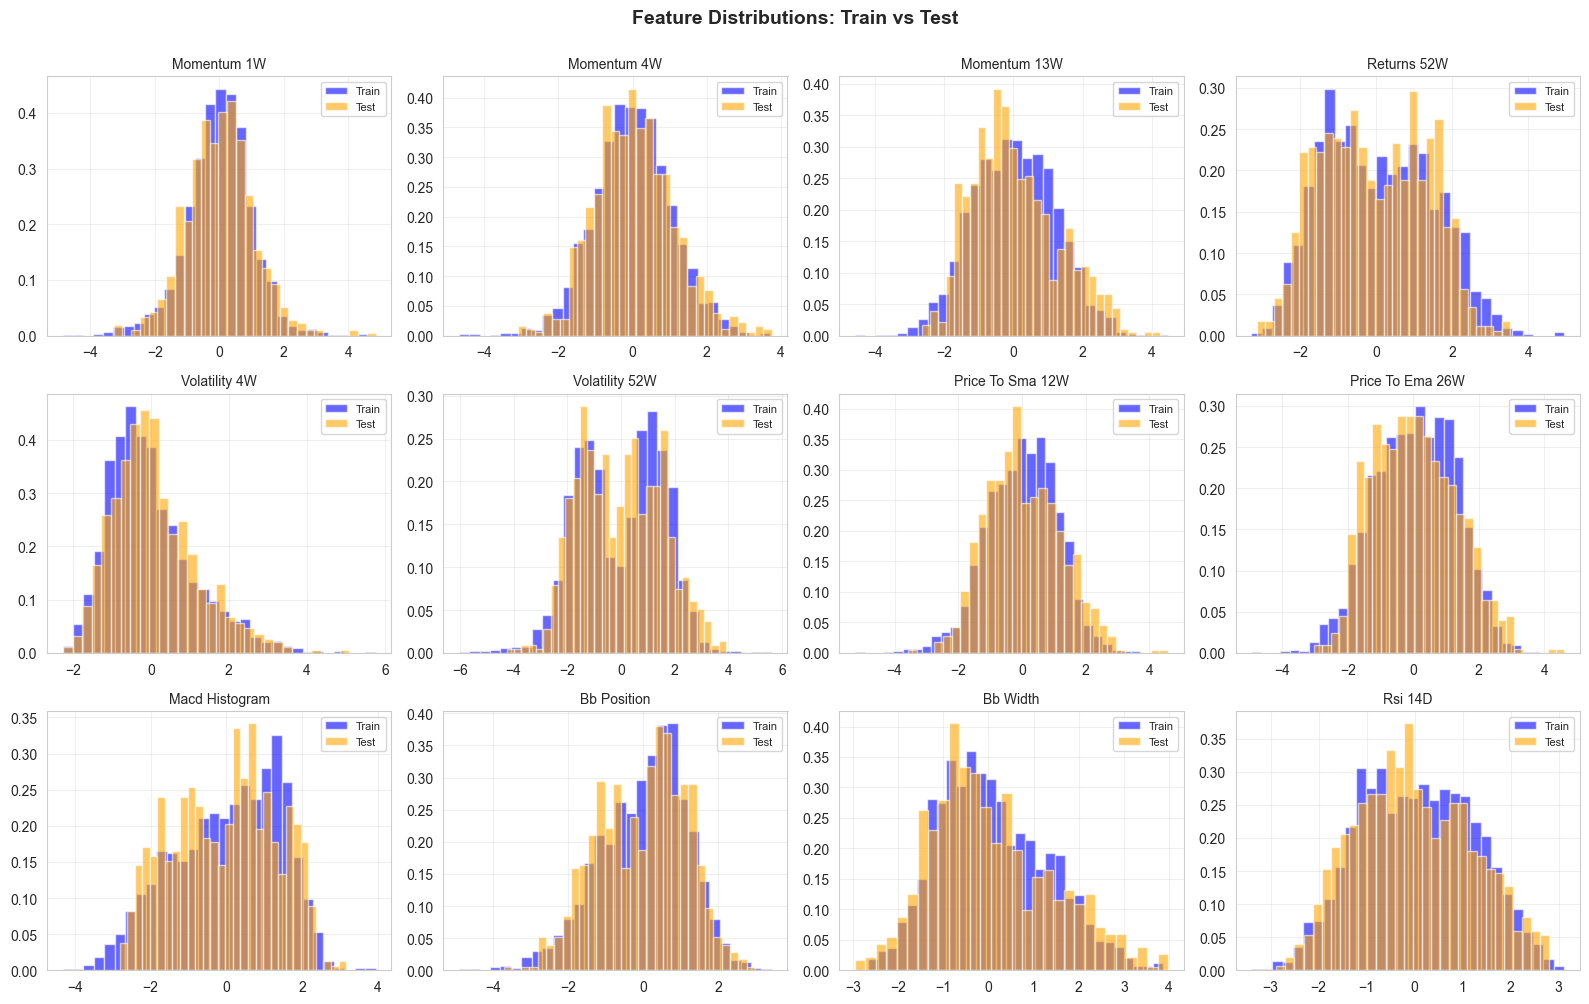

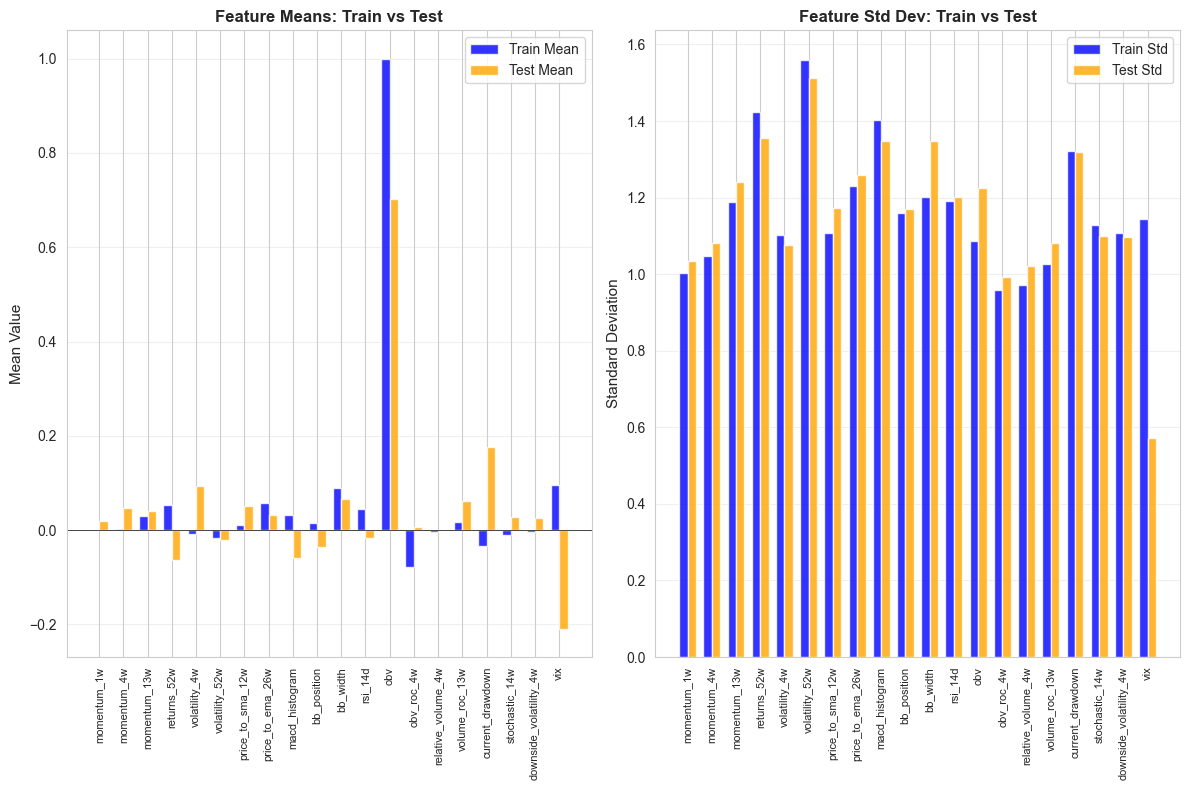

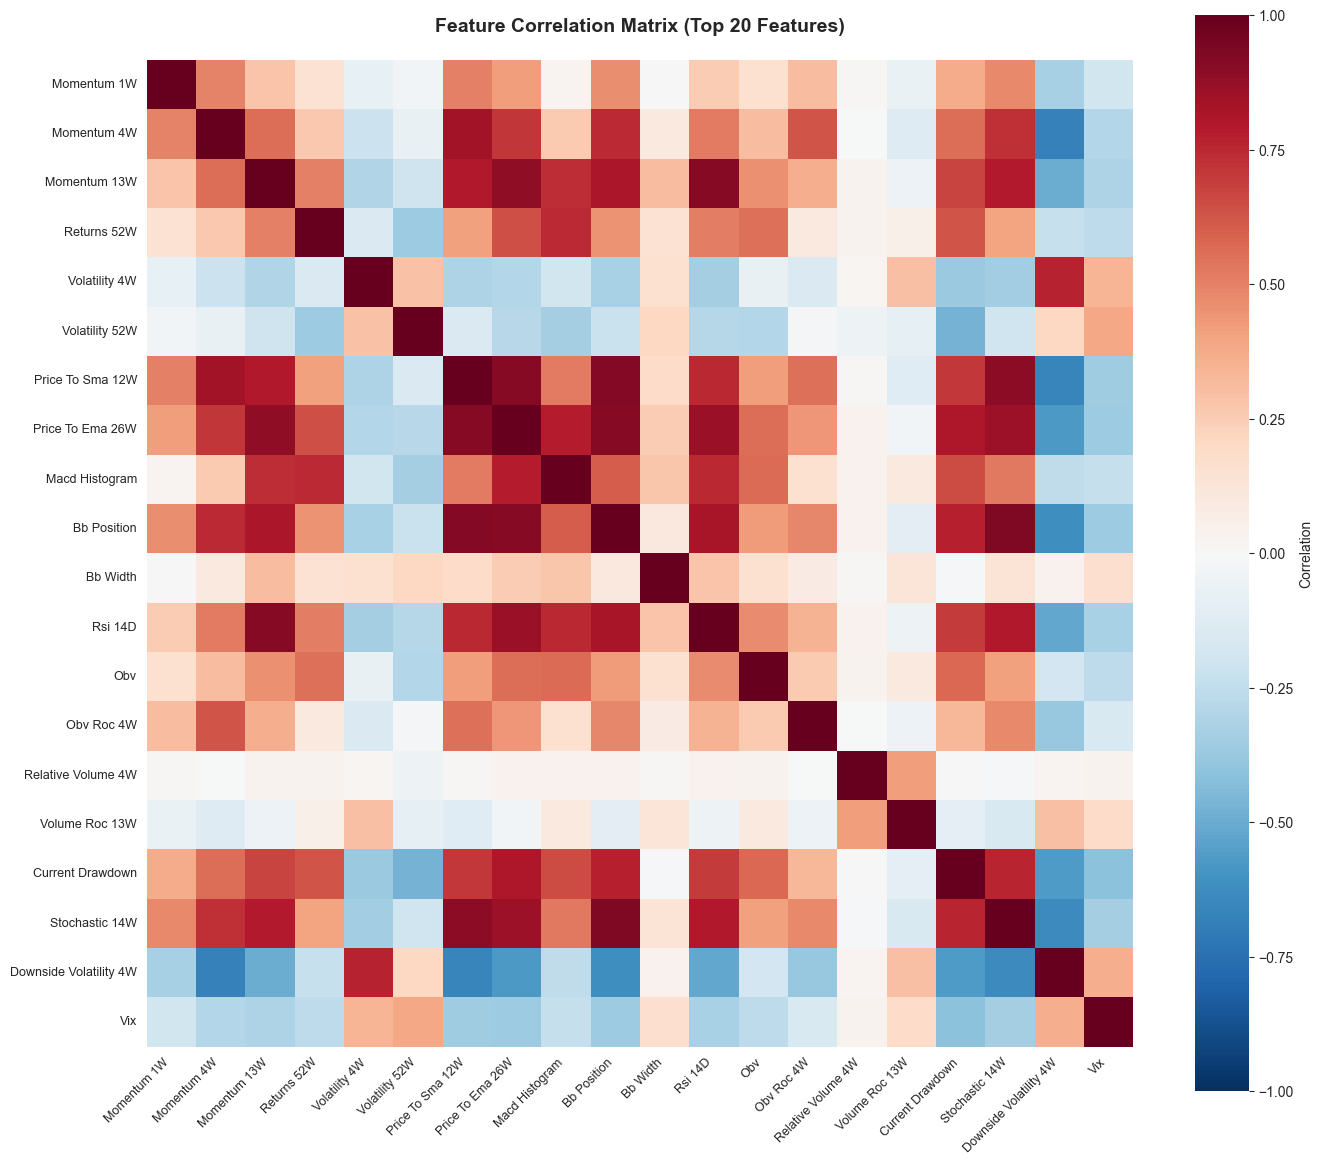

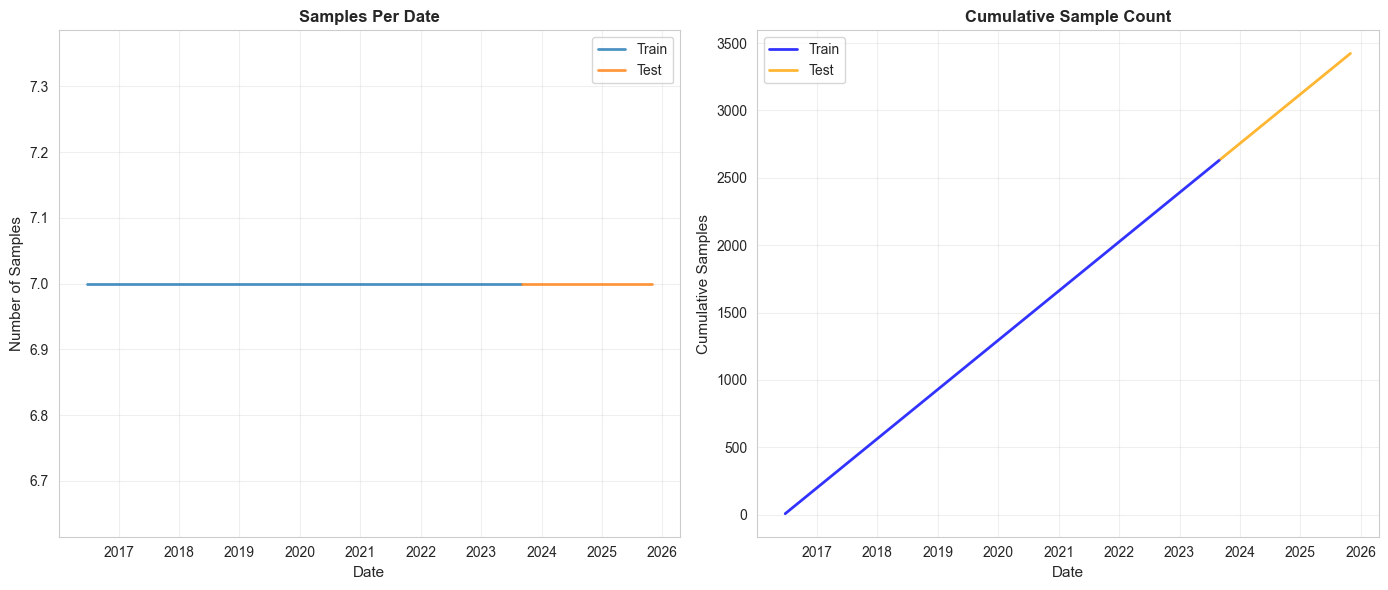


✓ Saved 5 plots to /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results


In [5]:
# Create all visualizations
figures = create_all_plots(
    train_df=train_df,
    test_df=test_df,
    tickers=TICKERS,
    feature_cols=feature_cols,
    output_dir=RESULTS_DIR
)

# Display in notebook
for name, fig in figures.items():
    plt.show()

print(f"\n✓ Saved {len(figures)} plots to {RESULTS_DIR}")

## View Metadata

In [6]:
print("\nMetadata:")
print(json.dumps(metadata, indent=2))


Metadata:
{
  "tickers": [
    "NVDA",
    "MU",
    "AAPL",
    "AMD",
    "ASML",
    "MSFT",
    "GOOG"
  ],
  "start_date": "2015-01-01",
  "end_date": "2025-11-01",
  "test_start_date": "2023-09-01",
  "interval": "1wk",
  "feature_cols": [
    "momentum_1w_norm",
    "momentum_4w_norm",
    "momentum_13w_norm",
    "returns_52w_norm",
    "volatility_4w_norm",
    "volatility_52w_norm",
    "price_to_sma_12w_norm",
    "price_to_ema_26w_norm",
    "macd_histogram_norm",
    "bb_position_norm",
    "bb_width_norm",
    "rsi_14d_norm",
    "obv_norm",
    "obv_roc_4w_norm",
    "relative_volume_4w_norm",
    "volume_roc_13w_norm",
    "current_drawdown_norm",
    "stochastic_14w_norm",
    "downside_volatility_4w_norm",
    "vix_norm",
    "dxy_norm",
    "oil_wti_norm",
    "treasury_10y_norm",
    "yield_curve_10y2y_norm",
    "month_sin",
    "month_cos"
  ],
  "n_features": 26,
  "ticker_features": [
    "momentum_1w_norm",
    "momentum_4w_norm",
    "momentum_13w_norm",
    

## Summary

### Pipeline Complete ✓

**Key Improvements Over Previous Version:**
- ✅ Reduced features: 100+ → 22 (evidence-based)
- ✅ Weekly frequency: Less noise, better for rebalancing
- ✅ Per-ticker normalization: Better cross-sectional comparison
- ✅ Clean code: Modular functions in `data_prep.py` and `viz_data_prep.py`

**Why This Matters:**
- Better sample-to-feature ratio → Less overfitting
- Literature-backed features → Better generalization
- Weekly data → More stable signals
- Per-ticker normalization → Fair comparison across assets

### Next Steps

1. **Train RL Agent**: Use processed data in `train_lstm_ppo.ipynb`
2. **Monitor Overfitting**: Watch for validation degradation
3. **Compare Results**: Benchmark against equal-weight baseline (Sharpe 1.174)
4. **Iterate**: Adjust LSTM size, patience, or features based on results